In [6]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
import random
import os

seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)
random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)


# Load Dataset

In [3]:
from tensorflow.keras.datasets import mnist

In [4]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print("Training data shape:", x_train.shape, y_train.shape)
print("Testing data shape:", x_test.shape, y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training data shape: (60000, 28, 28) (60000,)
Testing data shape: (10000, 28, 28) (10000,)


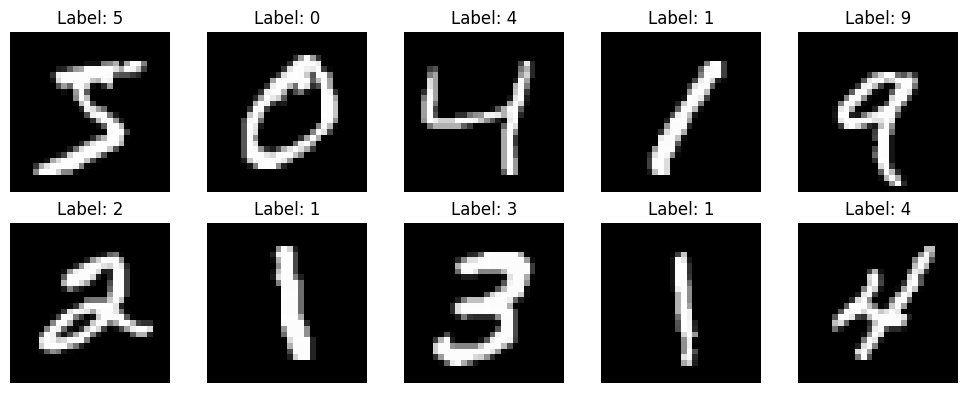

In [5]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

# Normalization [0,1]

In [7]:
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32') / 255.0

# Reshape (28,28,'1)

In [8]:
x_train = np.expand_dims(x_train, -1)
x_test  = np.expand_dims(x_test, -1)

# Validation Split

In [9]:
x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train,
    test_size=0.12,
    random_state=42,
    stratify=y_train
)

In [10]:
print("Train:", x_train.shape)
print("Validation:", x_val.shape)
print("Test:", x_test.shape)

Train: (52800, 28, 28, 1)
Validation: (7200, 28, 28, 1)
Test: (10000, 28, 28, 1)


# CNN Model (Baseline)

In [11]:
def build_baseline_cnn(input_shape=(28,28,1), num_classes=10):
    model = models.Sequential()
    # 1️⃣ Convolution Layer + Activation
    model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=input_shape))
    # 2️⃣ Pooling Layer
    model.add(layers.MaxPooling2D((2,2)))
    # 3️⃣ Convolution + Pooling
    model.add(layers.Conv2D(64, (3,3), activation='relu'))
    model.add(layers.MaxPooling2D((2,2)))
    # 4️⃣ Flatten
    model.add(layers.Flatten())
    # 5️⃣ Fully Connected Layer
    model.add(layers.Dense(128, activation='relu'))
    # 6️⃣ Dropout to reduce overfitting
    model.add(layers.Dropout(0.4))
    # 7️⃣ Output Layer
    model.add(layers.Dense(num_classes, activation='softmax'))
    return model

In [12]:
model = build_baseline_cnn()

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

# Callbacks (EarlyStopping + ModelCheckpoint)

In [13]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

checkpoint_path = "mnist_best_model.h5"

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        checkpoint_path,
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    )
]


# Train CNN Model

In [14]:
history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=30,
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8162 - loss: 0.5954
Epoch 1: val_loss improved from inf to 0.10105, saving model to mnist_best_model.h5


413/413 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.8165 - loss: 0.5947 - val_accuracy: 0.9688 - val_loss: 0.1010 - learning_rate: 0.0010
Epoch 2/30
411/413 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9708 - loss: 0.0969
Epoch 2: val_loss improved from 0.10105 to 0.06148, saving model to mnist_best_model.h5


413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9708 - loss: 0.0968 - val_accuracy: 0.9833 - val_loss: 0.0615 - learning_rate: 0.0010
Epoch 3/30
410/413 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9805 - loss: 0.0639
Epoch 3: val_loss improved from 0.06148 to 0.04859, saving model to mnist_best_model.h5


413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9805 - loss: 0.0639 - val_accuracy: 0.9867 - val_loss: 0.0486 - learning_rate: 0.0010
Epoch 4/30
410/413 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9844 - loss: 0.0524
Epoch 4: val_loss improved from 0.04859 to 0.04466, saving model to mnist_best_model.h5


413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9844 - loss: 0.0524 - val_accuracy: 0.9883 - val_loss: 0.0447 - learning_rate: 0.0010
Epoch 5/30
406/413 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9875 - loss: 0.0420
Epoch 5: val_loss did not improve from 0.04466
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9875 - loss: 0.0420 - val_accuracy: 0.9871 - val_loss: 0.0455 - learning_rate: 0.0010
Epoch 6/30
405/413 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9884 - loss: 0.0373
Epoch 6: val_loss improved from 0.04466 to 0.04151, saving model to mnist_best_model.h5


413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9884 - loss: 0.0373 - val_accuracy: 0.9878 - val_loss: 0.0415 - learning_rate: 0.0010
Epoch 7/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9895 - loss: 0.0333
Epoch 7: val_loss did not improve from 0.04151
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9895 - loss: 0.0333 - val_accuracy: 0.9874 - val_loss: 0.0479 - learning_rate: 0.0010
Epoch 8/30
408/413 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9906 - loss: 0.0290
Epoch 8: val_loss did not improve from 0.04151
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9906 - loss: 0.0290 - val_accuracy: 0.9890 - val_loss: 0.0422 - learning_rate: 0.0010
Epoch 9/30
409/413 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9923 - loss: 0.0250
Epoch 9: val_loss did not improve from 0.04151

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9922 - loss: 0.0250 - val_accuracy: 0.9886 - v

# Evaluate Model

In [15]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f" Test Accuracy: {test_acc:.4f}")
print(f" Test Loss: {test_loss:.4f}")

 Test Accuracy: 0.9905
 Test Loss: 0.0286


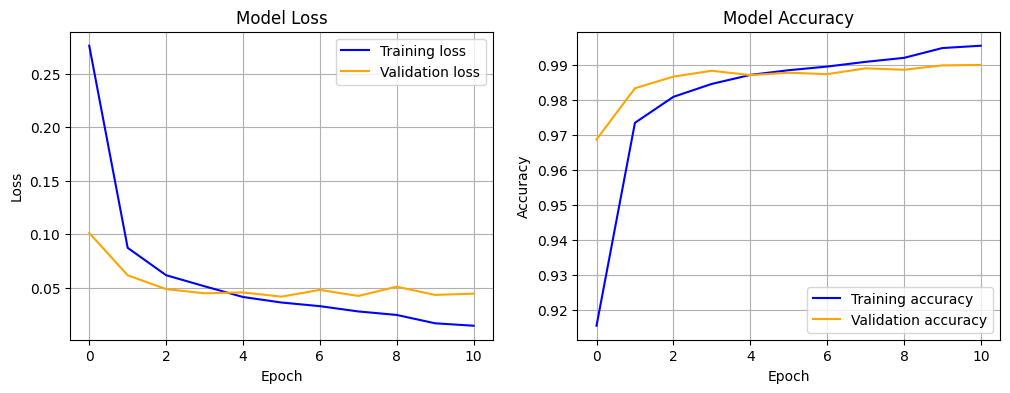

In [20]:
plt.figure(figsize=(12, 4))

# loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation loss', color='orange')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
# accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation accuracy', color='orange')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

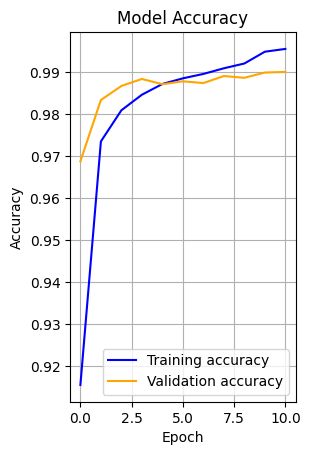

In [18]:
# accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation accuracy', color='orange')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

# Misclassified Images


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
num : 95 from 10000 image


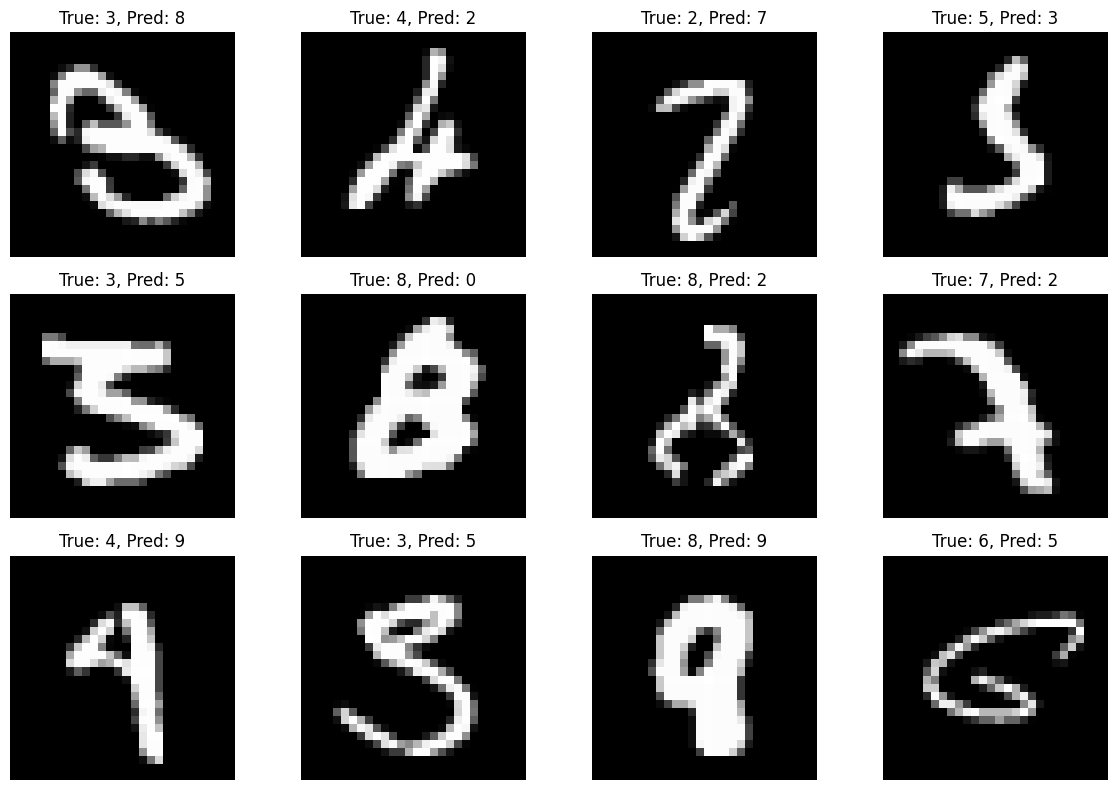

In [19]:
y_pred = np.argmax(model.predict(x_test), axis=1)

misclassified_idx = np.where(y_pred != y_test)[0]

print(f"num : {len(misclassified_idx)} from {len(x_test)} image")

plt.figure(figsize=(12, 8))
for i, idx in enumerate(misclassified_idx[:12]):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_test[idx].squeeze(), cmap='gray')
    plt.title(f"True: {y_test[idx]}, Pred: {y_pred[idx]}")
    plt.axis('off')

plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


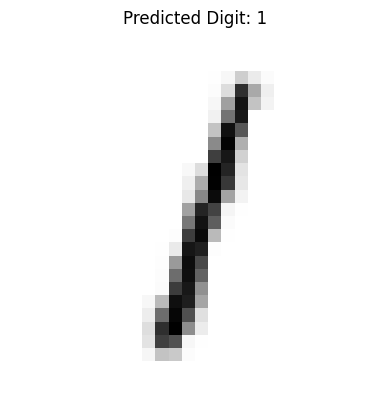

In [31]:
#Test the model on your own image

import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('/content/digit1.png', cv2.IMREAD_GRAYSCALE)

img = cv2.resize(img, (28, 28))

img = cv2.bitwise_not(img)

img = img.astype('float32') / 255.0

img = np.expand_dims(img, axis=(0, -1))

prediction = model.predict(img)
predicted_class = np.argmax(prediction)

plt.imshow(img[0].squeeze(), cmap='gray')
plt.title(f"Predicted Digit: {predicted_class}")
plt.axis('off')
plt.show()
